In [1]:
import pandas as pd
from prophet import Prophet
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS

c:\Users\usuario\Desktop\Extra\Reservoir\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
water_engineered_path = PATHS['engineered_data'] / 'water_engineered.parquet'
df = pd.read_parquet(water_engineered_path)
df.head()

,date,storage,capacity,crest_elevation,province,autonomous_community,id,year,month,day,storage_missing,storage_last_week_1,storage_last_week_2,storage_last_week_3,storage_last_week_4,storage_last_year,storage_mean_4w,storage_std_4w
0,1988-01-05,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,5,0,NaN,NaN,NaN,NaN,NaN,103.0,NaN
1,1988-01-12,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,12,0,103.0,NaN,NaN,NaN,NaN,103.0,0.0
2,1988-01-19,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,19,0,103.0,103.0,NaN,NaN,NaN,103.0,0.0
3,1988-01-26,103.0,103.0,NaN,cordoba,andalucia,1,1988,1,26,0,103.0,103.0,103.0,NaN,NaN,103.0,0.0
4,1988-02-02,103.0,103.0,NaN,cordoba,andalucia,1,1988,2,2,0,103.0,103.0,103.0,103.0,NaN,103.0,0.0


In [25]:
prophet_df = df[['date', 'storage']]
prophet_df = prophet_df.rename(columns={'date': 'ds', 'storage': 'y'})

model = Prophet()
model.fit(prophet_df)

# 3. Create a DataFrame for future predictions (e.g., 30 periods ahead)
future = model.make_future_dataframe(periods=30)

# 4. Make predictions
forecast = model.predict(future)
print(forecast)

# 5. Plot the forecast
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)
plt.show()

# Display the forecasted values
display_cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
forecast[display_cols].tail(10)

KeyboardInterrupt: 

In [9]:
df_first_reservoir = df[df['id'] == 1]
df_first_reservoir = df_first_reservoir[['date', 'storage']]
df_first_reservoir = df_first_reservoir.rename(columns={'date': 'ds', 'storage': 'y'})
df_first_reservoir.set_index('ds', inplace=True)

In [19]:
# Split df_first_reservoir into train and test sets for comparison
df_train = df_first_reservoir.iloc[:-52]
df_test = df_first_reservoir.iloc[-52:]
df_train, df_test

(                y
 ds               
 1988-01-05  103.0
 1988-01-12  103.0
 1988-01-19  103.0
 1988-01-26  103.0
 1988-02-02  103.0
 ...           ...
 2008-11-25   31.0
 2008-12-02   31.0
 2008-12-09   32.0
 2008-12-16   32.0
 2008-12-23   33.0
 
 [1095 rows x 1 columns],
                y
 ds              
 2008-12-30  33.0
 2009-01-06  33.0
 2009-01-13  33.0
 2009-01-20  35.0
 2009-01-27  36.0
 2009-02-03  41.0
 2009-02-10  57.0
 2009-02-17  63.0
 2009-02-24  65.0
 2009-03-03  65.0
 2009-03-10  66.0
 2009-03-17  67.0
 2009-03-24  67.0
 2009-03-31  68.0
 2009-04-07  68.0
 2009-04-14  64.0
 2009-04-21  63.0
 2009-04-28  63.0
 2009-05-05  63.0
 2009-05-12  63.0
 2009-05-19  63.0
 2009-05-26  63.0
 2009-06-02  56.0
 2009-06-09  53.0
 2009-06-16  53.0
 2009-06-23  58.0
 2009-06-30  60.0
 2009-07-07  60.0
 2009-07-14  59.0
 2009-07-21  58.0
 2009-07-28  58.0
 2009-08-04  58.0
 2009-08-11  57.0
 2009-08-18  57.0
 2009-08-25  55.0
 2009-09-01  50.0
 2009-09-08  47.0
 2009-09-15  45.0
 2009

In [10]:
df_first_reservoir.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1147 entries, 1988-01-05 to 2009-12-22
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       1147 non-null   float64
dtypes: float64(1)
memory usage: 17.9 KB


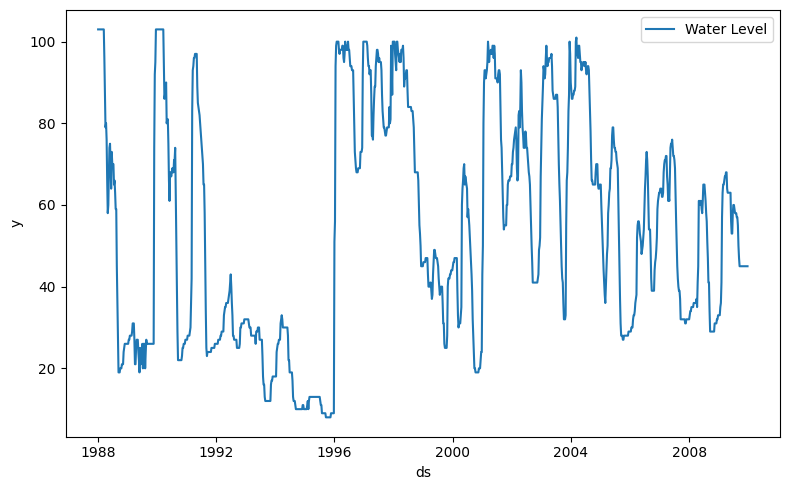

In [12]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df_first_reservoir, x=df_first_reservoir.index, y='y', label='Water Level')
plt.tight_layout()

12:54:44 - cmdstanpy - INFO - Chain [1] start processing
12:54:44 - cmdstanpy - INFO - Chain [1] done processing
12:54:44 - cmdstanpy - INFO - Chain [1] done processing


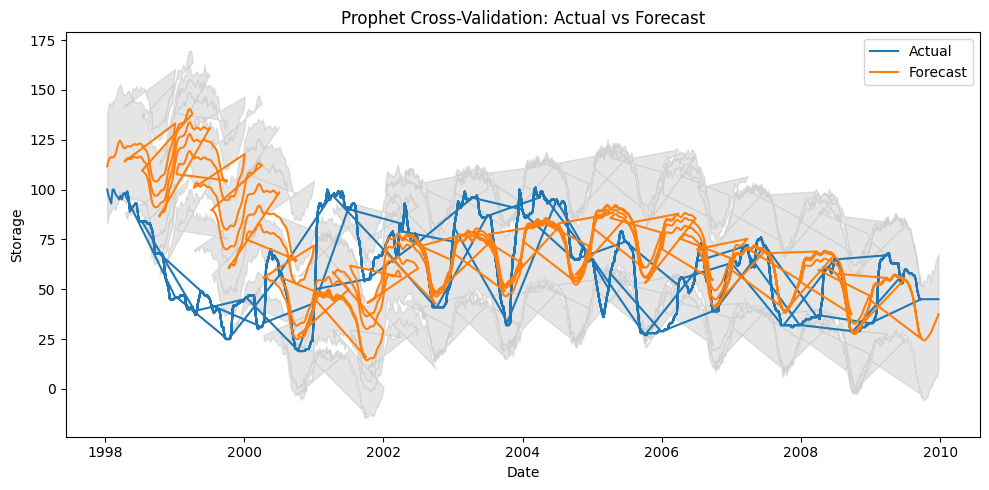

MAE: 23.684203829072306
RMSE: 31.429937544139033
MAPE: 0.5094806589657616


In [18]:
# Prophet time series cross-validation (KFold-like) for df_first_reservoir
from prophet.diagnostics import cross_validation, performance_metrics

# Prophet expects a DataFrame with columns 'ds' and 'y' (already set)
# 1. Fit the model on all available data
model = Prophet()
model.fit(df_first_reservoir.reset_index())

# 2. Cross-validation setup
# initial: training period length (e.g., 80% of data)
# period: spacing between cutoff dates (e.g., 30 days)
# horizon: forecast horizon (e.g., 30 days)
initial = 364*10
period = 364/4
horizon = 364

# Prophet's cross_validation expects string durations for period/horizon
cv_results = cross_validation(
    model,
    initial=f'{initial} days',
    period=f'{period} days',
    horizon=f'{horizon} days',
    parallel="processes"
)

# 3. Compute performance metrics
metrics = performance_metrics(cv_results)

# 4. Show key metrics
metrics[['horizon', 'mae', 'rmse', 'mape', 'coverage']].head()

# 5. Plot forecast vs. actuals for the last fold
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(cv_results['ds'], cv_results['y'], label='Actual')
plt.plot(cv_results['ds'], cv_results['yhat'], label='Forecast')
plt.fill_between(cv_results['ds'], cv_results['yhat_lower'], cv_results['yhat_upper'], color='gray', alpha=0.2)
plt.legend()
plt.title('Prophet Cross-Validation: Actual vs Forecast')
plt.xlabel('Date')
plt.ylabel('Storage')
plt.tight_layout()
plt.show()

# 6. Print summary statistics
print('MAE:', metrics['mae'].mean())
print('RMSE:', metrics['rmse'].mean())
print('MAPE:', metrics['mape'].mean())

13:05:38 - cmdstanpy - INFO - Chain [1] start processing
13:05:38 - cmdstanpy - INFO - Chain [1] done processing
13:05:38 - cmdstanpy - INFO - Chain [1] done processing


  horizon        mae       rmse      mape  coverage
0 14 days  15.559248  20.923666  0.400712  0.846154
1 21 days  15.650118  20.953780  0.399220  0.861079
2 28 days  15.602741  21.130960  0.399630  0.850459
3 35 days  15.787283  21.449918  0.407590  0.831228
4 42 days  15.970361  21.608180  0.412908  0.856774


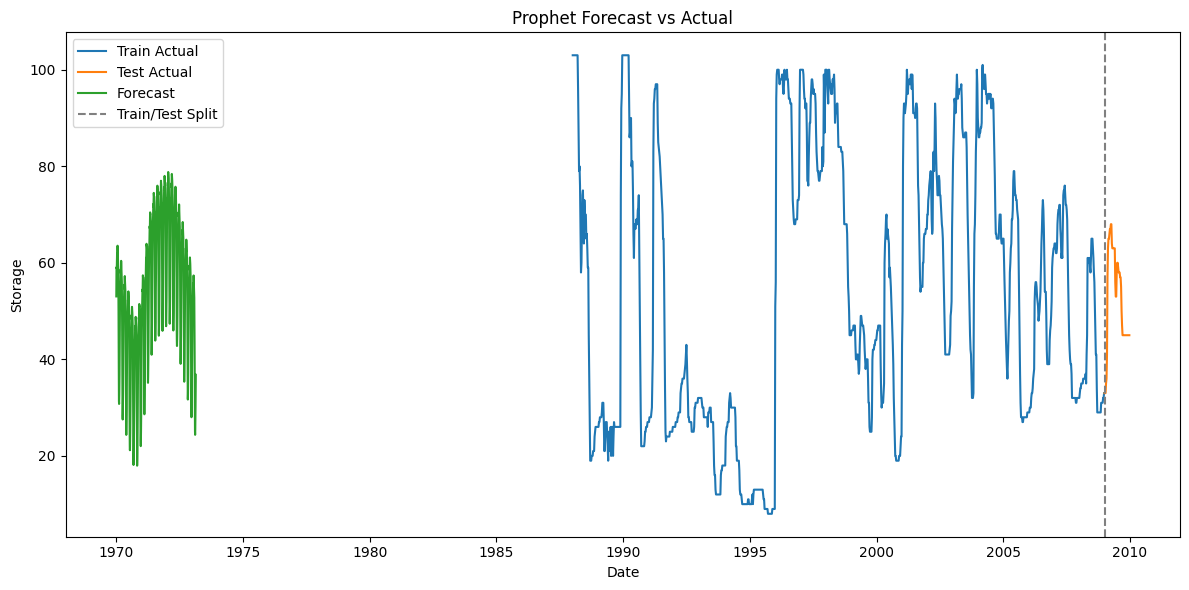

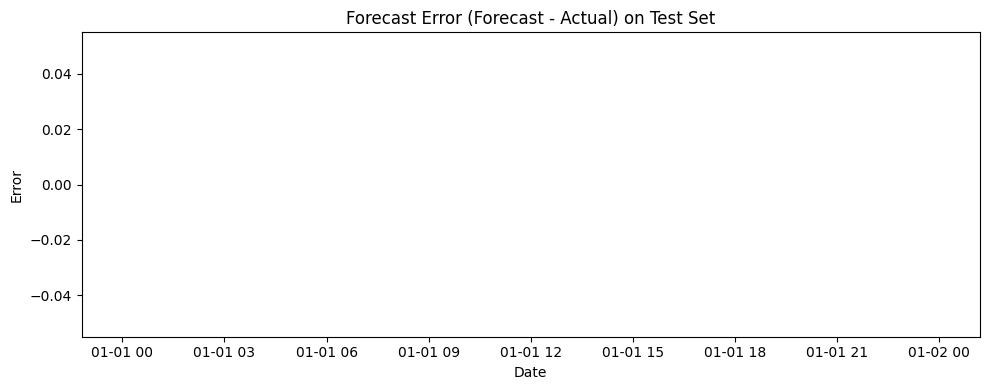

In [22]:
# Fit Prophet on training data, cross-validate, forecast 52 weeks ahead, compare to test set, and plot results
from prophet.diagnostics import cross_validation, performance_metrics
model = Prophet()
model.fit(df_train.reset_index())
# Cross-validation on training data (optional, can be commented out if not needed)
initial = int(len(df_train) * 0.8)
horizon = 13 # weeks
period = 4 # weeks
cv_results = cross_validation(
    model,
    initial=f'{initial}W',
    period=f'{period}W',
    horizon=f'{horizon}W',
    parallel="processes"
)
metrics = performance_metrics(cv_results)
print(metrics[['horizon', 'mae', 'rmse', 'mape', 'coverage']].head())
# Forecast 52 weeks ahead
future = model.make_future_dataframe(periods=52, freq='W')
forecast = model.predict(future)
# Align forecast with test set using reindex to avoid KeyError
forecast_test = forecast.set_index('ds').reindex(df_test.index)
# Plot actual vs forecast for the whole period
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(df_train.index, df_train['y'], label='Train Actual')
plt.plot(df_test.index, df_test['y'], label='Test Actual')
plt.plot(forecast.index, forecast['yhat'], label='Forecast')
plt.axvline(df_test.index[0], color='gray', linestyle='--', label='Train/Test Split')
plt.legend()
plt.title('Prophet Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Storage')
plt.tight_layout()
plt.show()
# Plot differences between forecast and test set
plt.figure(figsize=(10,4))
plt.plot(df_test.index, forecast_test['yhat'] - df_test['y'], marker='o')
plt.title('Forecast Error (Forecast - Actual) on Test Set')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show()

In [28]:
reservoir_id = 19
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train = series.iloc[:-52]
test = series.iloc[-52:]

22:02:09 - cmdstanpy - INFO - Chain [1] start processing
22:02:10 - cmdstanpy - INFO - Chain [1] done processing
22:02:10 - cmdstanpy - INFO - Chain [1] done processing


1865    15.220236
1866    14.879477
1867    14.706316
1868    14.765099
1869    15.050086
1870    15.453116
1871    15.814011
1872    16.013055
1873    16.041681
1874    16.014671
1875    16.117315
1876    16.501782
1877    17.180104
1878    17.993401
1879    18.708194
1880    19.184535
1881    19.471019
1882    19.728285
1883    20.050653
1884    20.372036
1885    20.560317
1886    20.594469
1887    20.616146
1888    20.784121
1889    21.091552
1890    21.362419
1891    21.445589
1892    21.393231
1893    21.416948
1894    21.661724
1895    22.044525
1896    22.332847
1897    22.371330
1898    22.208395
1899    22.001723
1900    21.833069
1901    21.647081
1902    21.362842
1903    21.002213
1904    20.675867
1905    20.452595
1906    20.276403
1907    20.027918
1908    19.648837
1909    19.181202
1910    18.688026
1911    18.165759
1912    17.557181
1913    16.840752
1914    16.080712
1915    15.378947
1916    14.793170
Name: yhat, dtype: float64


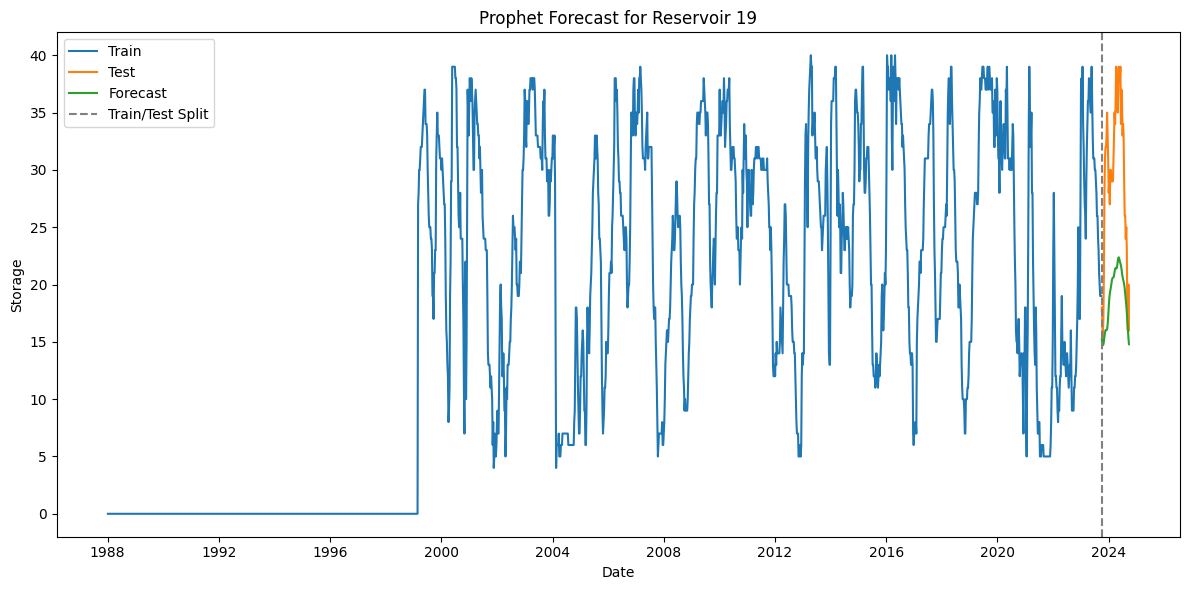

In [32]:
from backend.modeling.prophet_model import ProphetModel
# Create and train model
model = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=0.5)
model.fit(train)

# Make predictions
predictions = model.predict(52)
print(predictions)

# Evaluate and plot
metrics = model.evaluate(test, predictions)
model.plot_prediction(train, test, predictions, reservoir_id)

22:50:39 - cmdstanpy - INFO - Chain [1] start processing
22:50:39 - cmdstanpy - INFO - Chain [1] done processing
22:50:39 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:50:39 - cmdstanpy - INFO - Chain [1] start processing
22:50:39 - cmdstanpy - INFO - Chain [1] done processing


mae: 13.6824
mse: 324.1649
mape: 0.2152


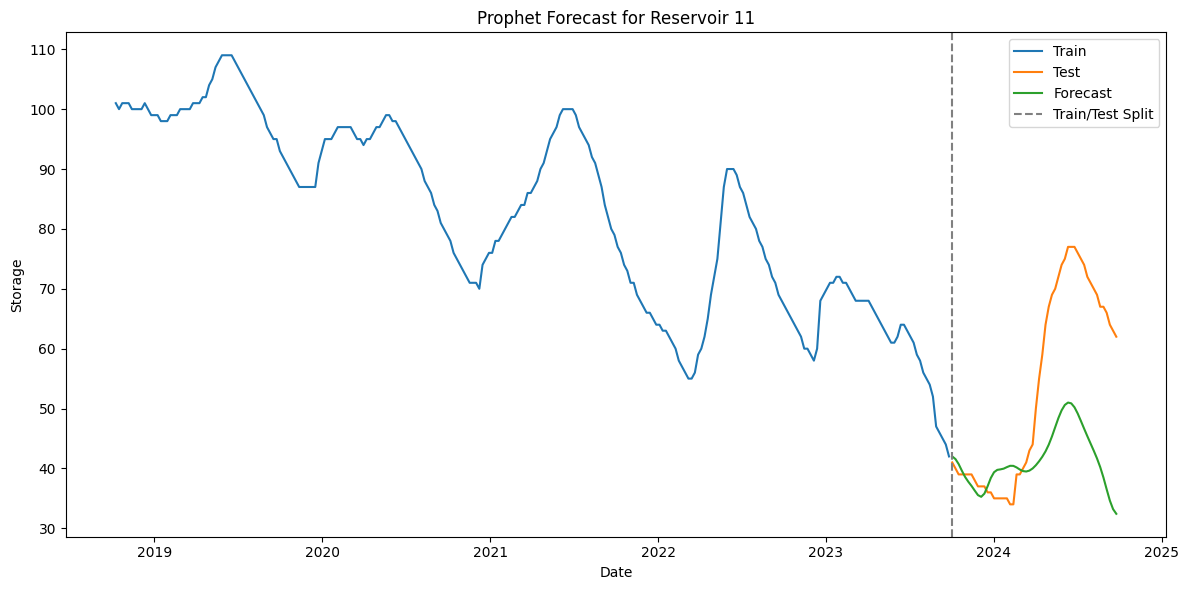

22:50:40 - cmdstanpy - INFO - Chain [1] start processing
22:50:40 - cmdstanpy - INFO - Chain [1] done processing
22:50:40 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
22:50:40 - cmdstanpy - INFO - Chain [1] start processing
22:50:40 - cmdstanpy - INFO - Chain [1] done processing


mae: 13.7411
mse: 327.3171
mape: 0.2159


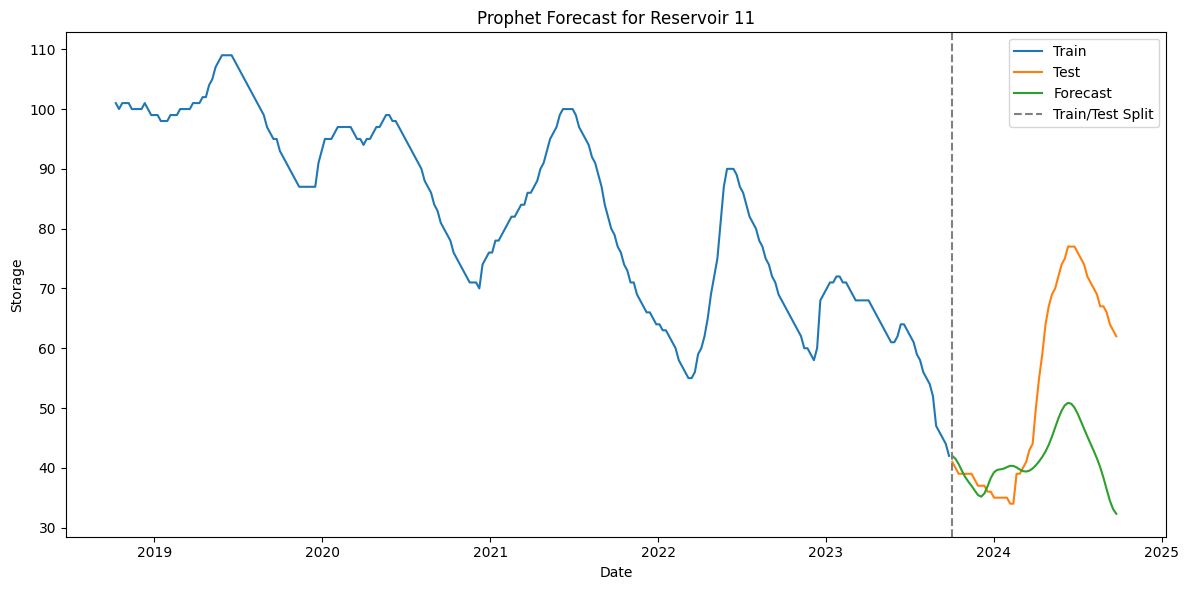

In [11]:
reservoir_id = 11
df_res = df[df['id'] == reservoir_id].copy()
df_res = df_res.sort_values('date')

# Set date as index
series = df_res.set_index('date')['storage']

# Train/test split: last 52 weeks as test
train = series.iloc[-(52)*6:-52]
test = series.iloc[-52:]

from backend.modeling.prophet_model import ProphetModel
# Create and train model
for i in [0.00005, 0.0001]:
    model = ProphetModel(yearly_seasonality=True, changepoint_prior_scale=i)
    model.fit(train)

    # Make predictions
    predictions = model.predict(52)
    # print(predictions)

    # Evaluate and plot
    metrics = model.evaluate(test, predictions)
    model.plot_prediction(train, test, predictions, reservoir_id)